<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
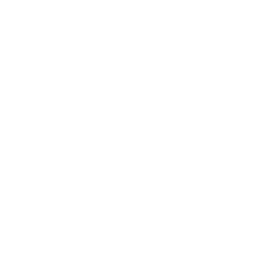
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">교육과정 유사성 분석</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 고등교육 / 학사 프로그램 설계 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 노트북은 **PROC DISTANCE**의 **METHOD=DJACCARD** — 이진 존재/부재 데이터의 자연스러운 거리인 Jaccard *비유사도(dissimilarity)* 계수 — 를 사용해 대학 강의 편람 전반의 교육과정 중복을 측정합니다. 각 강의는 어떤 인증 학습 성과를 다루는지 표시하는 40개의 이진 플래그를 지니므로, 두 강의 사이의 Jaccard 거리는 두 강의가 공통으로 **가지지 않는** 다뤄진 성과의 비율입니다(0 = 성과 집합이 동일, 1 = 공유 성과 없음).

분석은 두 부분으로 진행됩니다. 먼저 100개 강의 편람 전반에서 학과별 성과 커버리지 폭을 프로파일링하고(PROC MEANS, PROC FREQ, 커버리지 상자 그림), 한 학과의 **어떤** 강의도 다루지 않는 학습 성과(커버리지 공백)를 표시합니다. 다음으로 정량적으로 가장 많이 겹치는 두 학과 — 통계학과 데이터 과학 — 에서 뽑은 집중 10개 강의 패널로 파고들어, 전체 쌍별 Jaccard 거리 행렬을 계산하고, 가장 가까운 강의 쌍을 통합 검토 후보로 순위 매깁니다. 목표는 교육과정 위원회에 두 개의 구체적인 산출물을 제공하는 것입니다: 가장 유사한 강의의 순위 목록과 학과-성과 공백 지도.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | 강의별 이진 학습 성과 커버리지(40개 성과 플래그) | 100 |
| WORK.PANEL10 | 통계 + 데이터 과학 통합 패널 | 10 |

편람은 합성 데이터입니다. 성과 플래그는 학과별 확률로 뽑혀 학문 분야마다 서로 다른 성과 군집을 강조하도록 했으며(컴퓨터 과학과 수학은 앞쪽 성과에 가중치를, 실험 과학은 중간 대역에 가중치를 둠), 거리 분석에 현실적인 구조를 부여합니다. 이 환경은 라이선스 없이 실행되므로 작업 편람은 100개 강의로 제한됩니다.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic course learning-outcome matrix
   500 courses x 40 accreditation learning outcomes
   (unlicensed mode keeps the first 100)
   -------------------------------------------------------- */
데이터 work.course_outcomes;
    호출 streaminit(42);
    길이 department $30;
    배열 outcomes[40] lo_1 - lo_40;
    반복 course_id = 1 까지 500;
        course_label = cat('CRS', put(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        만약 dept_idx = 1 이면 department = '컴퓨터과학';
        아니면 만약 dept_idx = 2 이면 department = '수학';
        아니면 만약 dept_idx = 3 이면 department = '통계학';
        아니면 만약 dept_idx = 4 이면 department = '공학';
        아니면 만약 dept_idx = 5 이면 department = '생물학';
        아니면 만약 dept_idx = 6 이면 department = '화학';
        아니면 만약 dept_idx = 7 이면 department = '물리학';
        아니면 department = '데이터과학';
        /* Course level affects outcome breadth */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Department-specific outcome clusters */
        반복 lo = 1 까지 40;
            base_prob = 0.15;
            /* Dept 1-2 (CS, Math): emphasize outcomes 1-15 */
            만약 dept_idx <= 2 그리고 lo <= 15 이면
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Stats, Eng): emphasize outcomes 10-25 */
            아니면 만약 dept_idx IN (3, 4) 그리고 10 <= lo <= 25 이면
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Bio, Chem, Phys): emphasize 20-35 */
            아니면 만약 dept_idx IN (5, 6, 7) 그리고 20 <= lo <= 35 이면
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Data Sci): broad coverage */
            아니면 만약 dept_idx = 8 이면
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        종료;
        출력;
    종료;
    라벨 department='학과'
         level_code='과정 수준'
         course_label='과목 코드';
    제거 dept_idx course_level base_prob lo;
실행;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.87 seconds
  cpu   1.87 seconds


In [2]:
/* --------------------------------------------------------
   Generate course catalog metadata
   -------------------------------------------------------- */
데이터 work.course_catalog;
    호출 streaminit(43);
    길이 department $30 delivery_format $12;
    반복 course_id = 1 까지 500;
        course_label = cat('CRS-', put(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        만약 dept_idx = 1 이면 department = '컴퓨터과학';
        아니면 만약 dept_idx = 2 이면 department = '수학';
        아니면 만약 dept_idx = 3 이면 department = '통계학';
        아니면 만약 dept_idx = 4 이면 department = '공학';
        아니면 만약 dept_idx = 5 이면 department = '생물학';
        아니면 만약 dept_idx = 6 이면 department = '화학';
        아니면 만약 dept_idx = 7 이면 department = '물리학';
        아니면 department = '데이터과학';
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        만약 format_idx = 1 이면 delivery_format = '강의';
        아니면 만약 format_idx = 2 이면 delivery_format = '실습';
        아니면 delivery_format = '세미나';
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        출력;
    종료;
    라벨 department='학과'
         level_code='과정 수준'
         delivery_format='수업 형태'
         credit_hours='학점'
         enrollment_cap='정원'
         avg_enrollment='평균 수강인원';
    제거 dept_idx format_idx;
    형식 last_offered date9.;
실행;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

                                                    학과별 학습성과 평균 커버리지                                                    

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                         학과                 Obs           Mean
                                         -------------------------------------
                                         공학                  17      0.0000000
                                         데이터과학               14      0.1428571
                                         물리학                  7      0.2857143
                                         생물학                 10      0.2000000
                                         수학                   9      0.6666667
                                         컴퓨터과학               13      0.3846154
                                      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


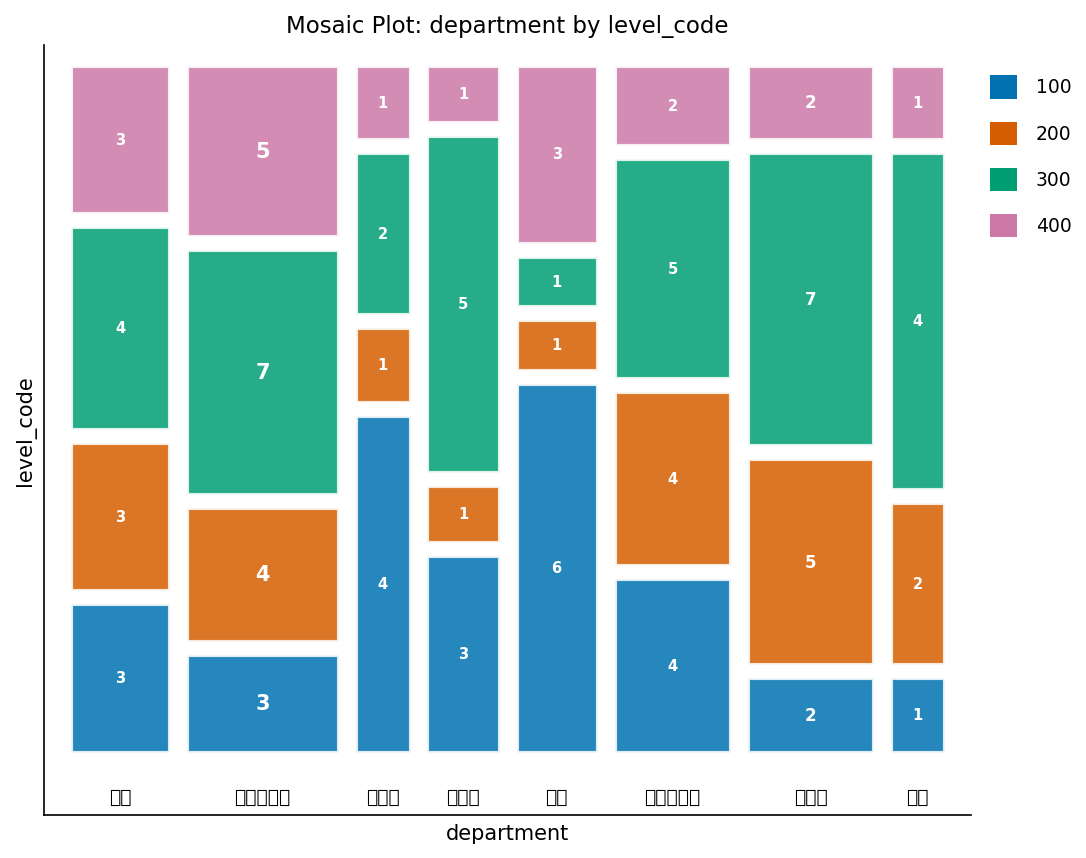

In [3]:
/* --------------------------------------------------------
   Baseline learning outcome coverage by department
   -------------------------------------------------------- */
처리 평균 데이터=work.course_outcomes mean;
    분류 department;
    변수 lo_1 - lo_40;
    제목 '학과별 학습성과 평균 커버리지';
실행;

처리 빈도 데이터=work.course_catalog;
    tables department * level_code / nopercent norow nocol;
    제목 '학과 × 과정 수준 교차표';
실행;

---

                                                     학과 × 과정 수준 교차표                                                     




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


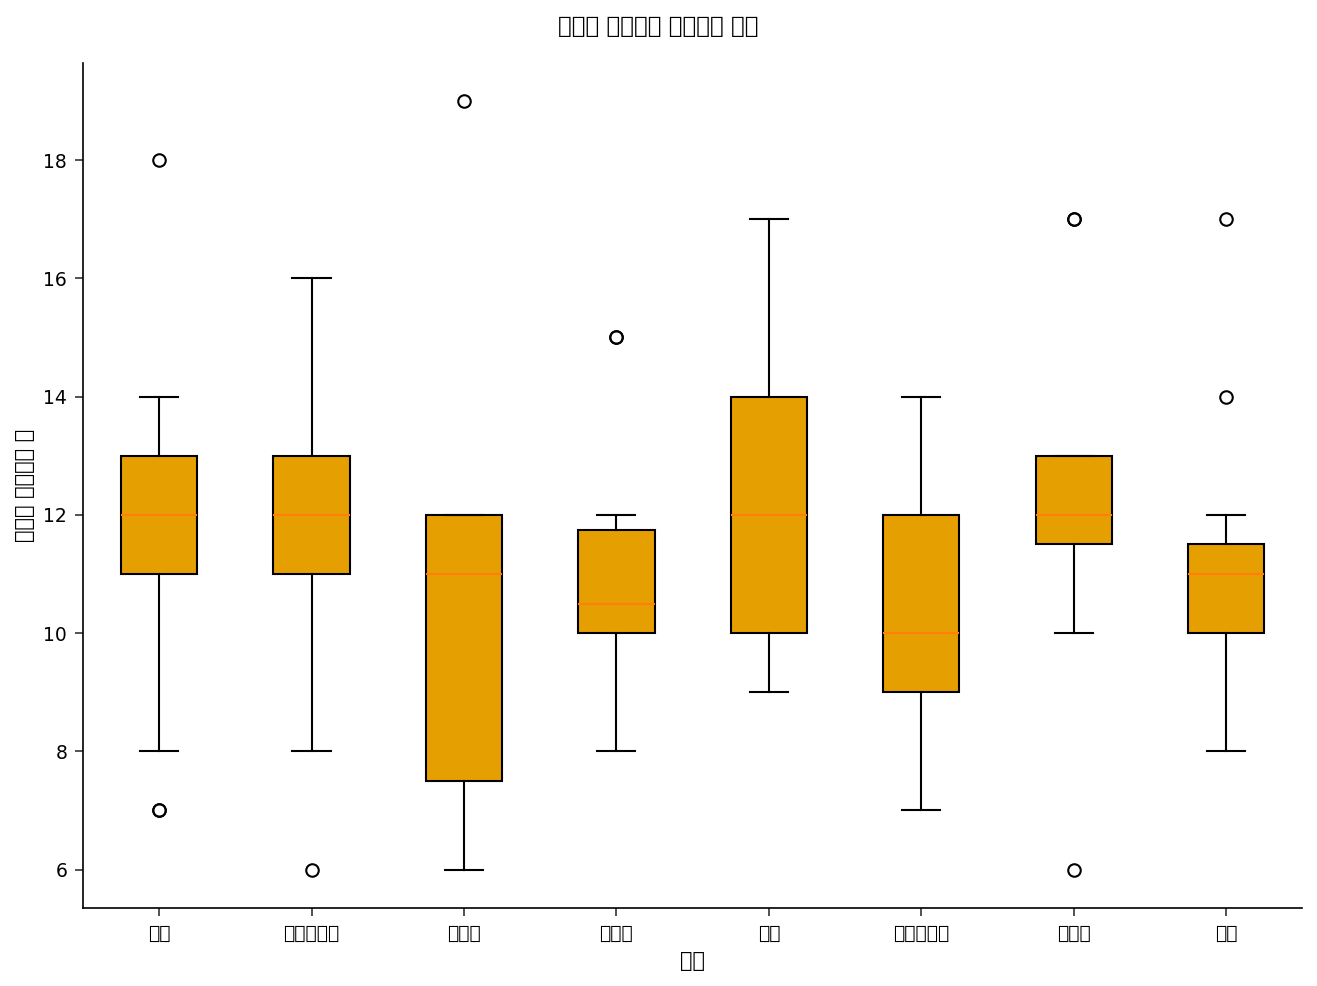

In [4]:
/* --------------------------------------------------------
   Outcome coverage density by department
   -------------------------------------------------------- */
데이터 work.outcome_counts;
    설정 work.course_outcomes;
    배열 outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(of outcomes[*]);
실행;

처리 sgplot 데이터=work.outcome_counts;
    vbox total_outcomes / category=department;
    yaxis label='커버된 학습성과 수';
    xaxis label='학과';
    제목 '학과별 학습성과 커버리지 분포';
실행;

---

In [5]:
/* --------------------------------------------------------
   Consolidation panel: the first 10 Statistics / Data
   Science courses (the two most quantitatively overlapping
   departments). Re-label them P01-P10 with a sequential
   counter so the square OUT= distance matrix has clean,
   addressable columns, then compute the full pairwise
   Jaccard DISTANCE matrix with METHOD=DJACCARD
   (0 = identical outcome sets, 1 = no shared outcome).
   -------------------------------------------------------- */
데이터 work.panel10;
    설정 work.course_outcomes(조건=(department IN ('통계학' '데이터과학')));
    보존 seq 0;
    seq + 1;
    만약 seq > 10 이면 중지;
    panel_id = cat('P', put(seq, z2.));
    제거 seq;
실행;

처리 인쇄 데이터=work.panel10 noobs 라벨;
    변수 panel_id course_label department level_code;
    라벨 panel_id = '패널 ID' course_label = '과목'
          department = '학과' level_code = '수준';
    제목 '통합 검토 패널: 통계학·데이터과학 과목';
실행;

처리 distance 데이터=work.panel10
              out=work.panel_dist
              method=djaccard;
    변수 nominal(lo_1 - lo_40);
    id panel_id;
실행;

처리 인쇄 데이터=work.panel_dist noobs;
    제목 '쌍별 자카드 거리 행렬 (10개 과목)';
실행;

                                                 통합 검토 패널: 통계학·데이터과학 과목                                                 

    패널 ID       과목               학과      수준
P01        CRS0003  데이터과학               300
P02        CRS0006  통계학                 300
P03        CRS0014  데이터과학               300
P04        CRS0015  통계학                 300
P05        CRS0017  통계학                 200
P06        CRS0019  데이터과학               100
P07        CRS0022  통계학                 400
P08        CRS0033  데이터과학               200
P09        CRS0038  통계학                 100
P10        CRS0040  통계학                 100

                                                 통합 검토 패널: 통계학·데이터과학 과목                                                 

                                                 쌍별 자카드 거리 행렬 (10개 과목)                                                  

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P0


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reshape the square distance matrix into a ranked list of
   course pairs. The OUT= distance columns are addressed by
   an explicit name list (P01 P02 ... P10); only the strict
   upper triangle (col > row) is kept so each unordered pair
   appears once and the zero diagonal is skipped. The five
   closest pairs are the consolidation-review candidates.
   -------------------------------------------------------- */
데이터 work.similar_courses;
    설정 work.panel_dist;
    배열 d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    길이 course_a course_b $8;
    course_a = _name_;
    row + 1;
    반복 col = 1 까지 10;
        만약 col > row 이면 반복;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            출력;
        종료;
    종료;
    유지 course_a course_b jaccard_dist;
실행;

처리 평균 데이터=work.similar_courses n min q1 median mean max maxdec=3;
    변수 jaccard_dist;
    라벨 jaccard_dist='자카드 거리';
    제목 '쌍별 자카드 거리 분포 (45개 과목 쌍)';
실행;

처리 정렬 데이터=work.similar_courses; 기준 jaccard_dist; 실행;

데이터 work.top_pairs;
    설정 work.similar_courses;
    pair_rank = _n_;
    만약 pair_rank <= 5;
실행;

처리 인쇄 데이터=work.top_pairs noobs 라벨;
    변수 pair_rank course_a course_b jaccard_dist;
    라벨 pair_rank = '순위' course_a = '과목 A'
          course_b = '과목 B' jaccard_dist = '자카드 거리';
    제목 '가장 가까운 5개 과목 쌍 (통합 후보)';
실행;

                                                쌍별 자카드 거리 분포 (45개 과목 쌍)                                                 

                                                  The MEANS Procedure

 Variable      Label                   N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------------------------
 jaccard_dist  자카드 거리                 45       0.588            0.762       0.826       0.818       0.962
 --------------------------------------------------------------------------------------------------------

                                                 가장 가까운 5개 과목 쌍 (통합 후보)                                                 

    순위      과목 A      과목 B            자카드 거리
     1  P02       P10                  0.588
     2  P03       P04                    0.6
     3  P03       P05                  0.667
     4  P02       P04                  0.684
     5  P02       P07              


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                                      학과별 미달성 학습성과                                                      

                                                   The FREQ Procedure

학과                 Frequency    Percent
----------------------------------------
공학                         2      6.67
물리학                        8     26.67
생물학                        8     26.67
수학                         4     13.33
컴퓨터과학                      3     10.00
통계학                        3     10.00
화학                         2      6.67
                                                성과 격차 표본 (30개 중 처음 12개)                                                 

       학과            미달성 성과
공학         LO01
공학         LO27
물리학        LO02
물리학        LO03
물리학        LO07
물리학        LO10
물리학        LO11
물리학        LO36
물리학        LO38
물리학        LO39
생물학        LO02
생물학        LO10

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


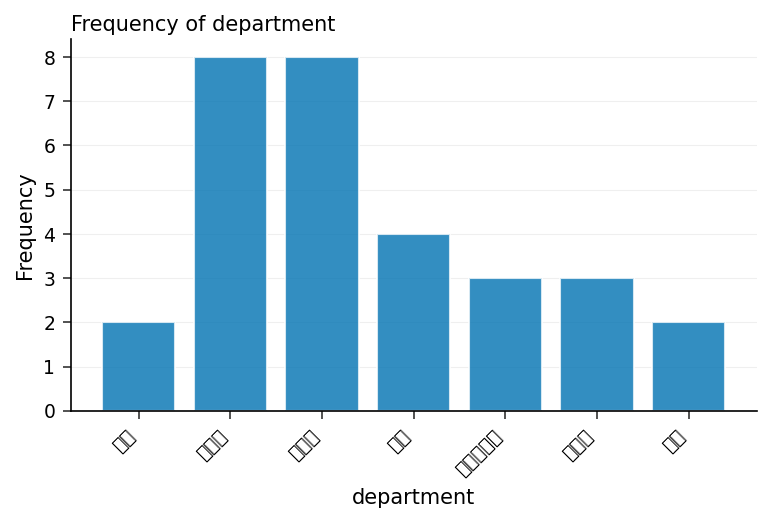

In [7]:
/* --------------------------------------------------------
   Outcome gaps: learning outcomes that NO course in a
   department covers. PROC MEANS sums each binary outcome
   flag within department; a sum of zero means the
   outcome is absent from that department's catalog.
   -------------------------------------------------------- */
처리 평균 데이터=work.course_outcomes sum noprint;
    분류 department;
    변수 lo_1 - lo_40;
    출력 out=work.dept_coverage(조건=(_type_=1))
        sum=lo_1 - lo_40;
실행;

데이터 work.outcome_gaps;
    설정 work.dept_coverage;
    길이 outcome_id $6;
    배열 outcomes[40] lo_1 - lo_40;
    반복 lo = 1 까지 40;
        outcome_id = cat('LO', put(lo, z2.));
        courses_covering = outcomes[lo];
        만약 courses_covering = 0 이면 반복;
            gap_flag = 1;
            출력;
        종료;
    종료;
    라벨 department='학과' outcome_id='미달성 성과';
    유지 department outcome_id courses_covering gap_flag;
실행;

처리 빈도 데이터=work.outcome_gaps;
    tables department / nocum;
    제목 '학과별 미달성 학습성과';
실행;

처리 인쇄 데이터=work.outcome_gaps(obs=12) noobs 라벨;
    변수 department outcome_id;
    라벨 department = '학과' outcome_id = '미달성 성과';
    제목 '성과 격차 표본 (30개 중 처음 12개)';
실행;

---

### 해석

**통합 패널.** 10개 강의로 이루어진 통계 / 데이터 과학 패널의 45개 순서 없는 쌍 전반에서 Jaccard 거리는 0.588에서 0.962까지 분포하며 중앙값은 0.826(평균 0.818)입니다. 가장 가까운 쌍은 거리 0.588의 P02와 P10이고, 뒤이어 0.600의 P03–P04, 0.667의 P03–P05가 옵니다. 가장 유사한 강의들조차 다뤄진 성과의 약 59%에서 여전히 다르므로, 이 편람에는 **거의 중복인 강의가 없습니다** — 위원회가 곧바로 병합할 수 있는 쌍은 없습니다. 순위 목록은 대신 다음 편람 주기 전에 수동으로 강의계획서를 비교해 볼 만한 소수의 쌍을 가리킵니다. 거리가 가장 큰 쌍(0.962 부근)은 통계학과 데이터 과학 강의가 같은 학과 이웃을 공유하면서도 진정으로 구분되는 성과 집합에 걸쳐 있음을 확인해 줍니다.

**성과 공백.** 편람 전반에서 서른 개의 학과-성과 공백이 드러납니다. 실험 중심 분야가 가장 많습니다: **생물학**과 **물리학**은 각각 40개 인증 성과 중 8개를 다루지 않으며, 그 뒤를 **수학**(4)이 잇습니다. 정량 학과가 가장 잘 다룹니다 — **화학**과 **공학**은 각각 2개만 놓칩니다. 이 공백들은 신규 강의 개발이나 교차 등재(cross-listing)의 자연스러운 대상입니다: 한 학과 전체에서 빠진 성과는 인증 갱신 시 커버리지 위험이 되는 반면, 통합 목록은 노력 중복이라는 반대 문제를 다룹니다. 이 두 산출물을 함께 쓰면 위원회는 하나의 집합 기반 거리 측도로 편람을 양쪽 끝에서 조일 수 있습니다 — 중복을 덜어내고 공백을 메우면서.

---

In [8]:
/* --------------------------------------------------------
   Export the ranked consolidation candidates and the
   department outcome-gap map for the curriculum committee.
   -------------------------------------------------------- */
처리 export 데이터=work.similar_courses
    outfile='curriculum_consolidation_candidates.csv'
    dbms=csv replace;
실행;

처리 export 데이터=work.outcome_gaps
    outfile='curriculum_outcome_gaps.csv'
    dbms=csv replace;
실행;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>